# Project Part 2: Data Understanding and Preparation

- **Team number:** `#`
- **Team members:** `Cole Beach`, `Eric Lindquist`, `Tuan Lo`
- **Dataset name:** `Music Genre Classification Dataset (train.csv / test.csv)`
- **Target variable:** `Class`

## 1. Problem and Data Snapshot

- **Dataset:** We use the music classification dataset from `data/raw/train.csv` for training and `data/raw/test.csv` for prediction.
- **Machine learning problem:** This is a supervised multiclass classification problem because each song has a labeled category.
- **Target variable:** The output to predict is `Class`.
- **Main input features expected to be used:**
  - Metadata features: `Artist Name`, `Track Name`, `Popularity`
  - Audio features: `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_in min/ms`, `time_signature`

This project aims to learn patterns from track metadata and acoustic descriptors that are useful for predicting the correct music class.

## 2. Exploratory Data Analysis

This EDA uses a selective set of variables chosen for modeling relevance, distribution behavior, missingness, and relationship strength.

Dataset snapshot first: we verify overall size (`df.shape`) and schema (`df.info()` style view) so preprocessing decisions are grounded in sample size, numeric coverage, and missingness concentration. The data has enough observations for multiclass modeling, while missingness is concentrated in only a few features rather than spread uniformly.

**Focused variables:** `Popularity`, `energy`, `loudness`, `acousticness`, `instrumentalness`, `duration_in min/ms`, `speechiness`, `tempo` (target: `Class`).

### 2.1. EDA Context Snapshot

This subsection standardizes reusable constants, plotting style, and a compact data snapshot.

The snapshot outputs are used to anchor later choices:
- Dataset size supports stratified validation without collapsing minority classes.
- Missingness concentration (instead of broad random gaps) supports targeted imputation over row dropping.
- The descriptive statistics and skew metrics identify where robust scaling and transform sensitivity checks are most important (`speechiness`, `acousticness`, `duration_in min/ms`, `instrumentalness`).

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================
# Configuration / Constants
# =========================
RANDOM_STATE = 42

DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

TARGET_COL = "Class"

FOCUSED_FEATURES = [
    "Popularity",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "duration_in min/ms",
    "speechiness",
    "tempo",
]

CATEGORICAL_SNAPSHOT_COLS = ["mode", "time_signature"]
BOUNDED_FEATURES_01 = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

PALETTE = "Set2"
CLASS_PALETTE = "tab20"
FIGSIZE_WIDE = (20, 9)
FIGSIZE_MED = (12, 6)
FIGSIZE_HEATMAP = (10, 7)
FIGSIZE_THREE_PANEL = (19, 5)
DPI = 110

sns.set_theme(style="whitegrid", context="notebook", palette=PALETTE)
plt.rcParams["figure.dpi"] = DPI

# Data loading and reusable views.
df = pd.read_csv(TRAIN_PATH)
eda_df = df[FOCUSED_FEATURES + [TARGET_COL]].copy()

# Stable ordering and color mapping for class-aware plots.
class_order = sorted(df[TARGET_COL].dropna().unique().tolist())
class_palette_map = dict(zip(class_order, sns.color_palette(CLASS_PALETTE, n_colors=len(class_order))))

# Compact snapshot before focused diagnostics.
print("Dataset shape (rows, cols):", df.shape)
print("Target column:", TARGET_COL)

schema_snapshot = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(3),
})

print("\nTop columns by missingness:")

audit = pd.DataFrame({
    "dtype": eda_df[FOCUSED_FEATURES].dtypes.astype(str),
    "missing_pct": (eda_df[FOCUSED_FEATURES].isna().mean() * 100).round(3),
    "n_unique": eda_df[FOCUSED_FEATURES].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

audit

Dataset shape (rows, cols): (17996, 17)
Target column: Class

Top columns by missingness:


,dtype,missing_pct,n_unique
instrumentalness,float64,24.322,4253
Popularity,float64,2.378,100
loudness,float64,0.000,9002
energy,float64,0.000,1208
acousticness,float64,0.000,3930
duration_in min/ms,float64,0.000,14121
speechiness,float64,0.000,1194
tempo,float64,0.000,13562


In [39]:
summary = eda_df[FOCUSED_FEATURES].describe(percentiles=[0.25, 0.5, 0.75]).T
summary = summary.rename(columns={"50%": "median", "25%": "q1", "75%": "q3"})
summary["iqr"] = summary["q3"] - summary["q1"]
summary["missing_pct"] = eda_df[FOCUSED_FEATURES].isna().mean() * 100
summary["skew"] = eda_df[FOCUSED_FEATURES].skew(numeric_only=True)

summary_table = summary[[
    "count",
    "missing_pct",
    "mean",
    "std",
    "min",
    "median",
    "max",
    "iqr",
    "skew",
]].round(3)

summary_table

,count,missing_pct,mean,std,min,median,max,iqr,skew
Popularity,17568.0,2.378,44.512,17.427,1.000,44.000,100.000,23.000,0.076
energy,17996.0,0.000,0.663,0.235,0.000,0.700,1.000,0.351,-0.661
loudness,17996.0,0.000,-7.911,4.049,-39.952,-7.016,1.355,4.349,-1.761
acousticness,17996.0,0.000,0.247,0.311,0.000,0.081,0.996,0.430,1.105
instrumentalness,13619.0,24.322,0.178,0.304,0.000,0.004,0.996,0.200,1.531
duration_in min/ms,17996.0,0.000,200744.459,111989.127,0.502,209160.000,1477187.000,86153.000,0.847
speechiness,17996.0,0.000,0.080,0.084,0.022,0.047,0.955,0.048,3.088
tempo,17996.0,0.000,122.623,29.572,30.557,120.066,217.416,42.348,0.380


- `instrumentalness` has substantial missingness relative to other focused features, which justifies explicit imputation policy testing.
- Multiple features show non-trivial skew (`speechiness`, `acousticness`, `loudness`, `duration_in min/ms`), which argues for robust scaling and possible transform ablations.
- Very different feature scales reinforce using a pipeline to prevent scale-dominated behavior in linear or distance-based models.

### 2.2. Label and Categorical Sanity Snapshot

This compact snapshot carries forward the strongest context before focused feature diagnostics.

Interpretation for modeling:
- Class counts and percentages confirm moderate imbalance, so later evaluation should emphasize macro-F1 / balanced accuracy rather than only overall accuracy.
- Minority classes should be preserved in every split, so stratified train/validation folds are required.
- Class-frequency imbalance also motivates testing class weights before more aggressive rebalancing methods.

,count,pct
Class,,
10,4949,27.50
6,2587,14.38
9,2524,14.03
8,1854,10.30
5,1447,8.04
1,1373,7.63
2,1272,7.07
0,625,3.47
7,576,3.20


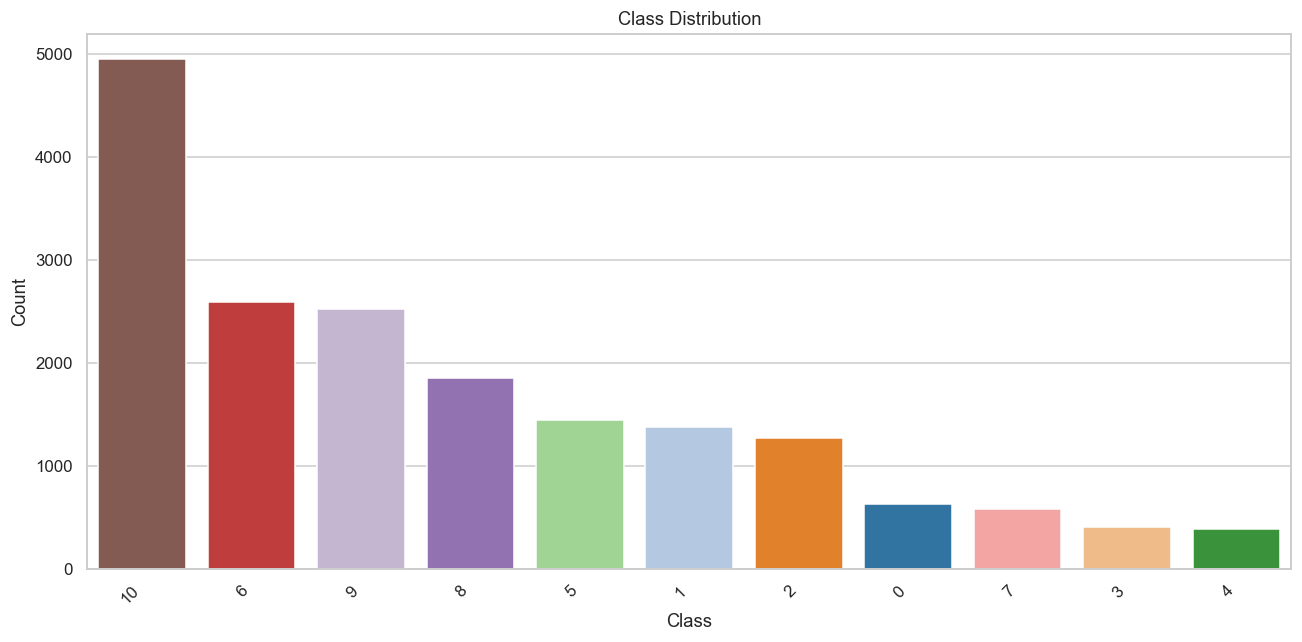

In [40]:
# Class distribution (counts + percentages) to support imbalance-aware modeling choices.
class_counts = df[TARGET_COL].value_counts().sort_values(ascending=False)
class_pct = (class_counts / class_counts.sum() * 100).round(2)

class_distribution = pd.DataFrame({
    "count": class_counts,
    "pct": class_pct,
})

display(class_distribution)

class_distribution_plot = class_distribution.reset_index().rename(columns={"index": TARGET_COL})

plt.figure(figsize=FIGSIZE_MED)
sns.barplot(
    data=class_distribution_plot,
    x=TARGET_COL,
    y="count",
    order=class_distribution.index.tolist(),
    hue=TARGET_COL,
    palette=class_palette_map,
    legend=False,
)
plt.title("Class Distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Why these class-distribution outputs matter:** The table and bar chart show that several classes are much smaller than the dominant class, so we should avoid random non-stratified splitting, track per-class errors, and prioritize macro-averaged metrics. This also supports trying class-weighted baselines before synthetic oversampling to reduce overfitting risk on minority classes.

In [57]:
# Quick categorical sanity checks.
for col in CATEGORICAL_SNAPSHOT_COLS:
    if col in df.columns:
        print(f"\nValue counts for {col}:")
        display(df[col].value_counts(dropna=False).to_frame("count"))


Value counts for mode:


,count
mode,
1,11459
0,6537



Value counts for time_signature:


,count
time_signature,
4,16451
3,1228
5,203
1,114


### 2.3. Focused Feature Distributions (Histogram)

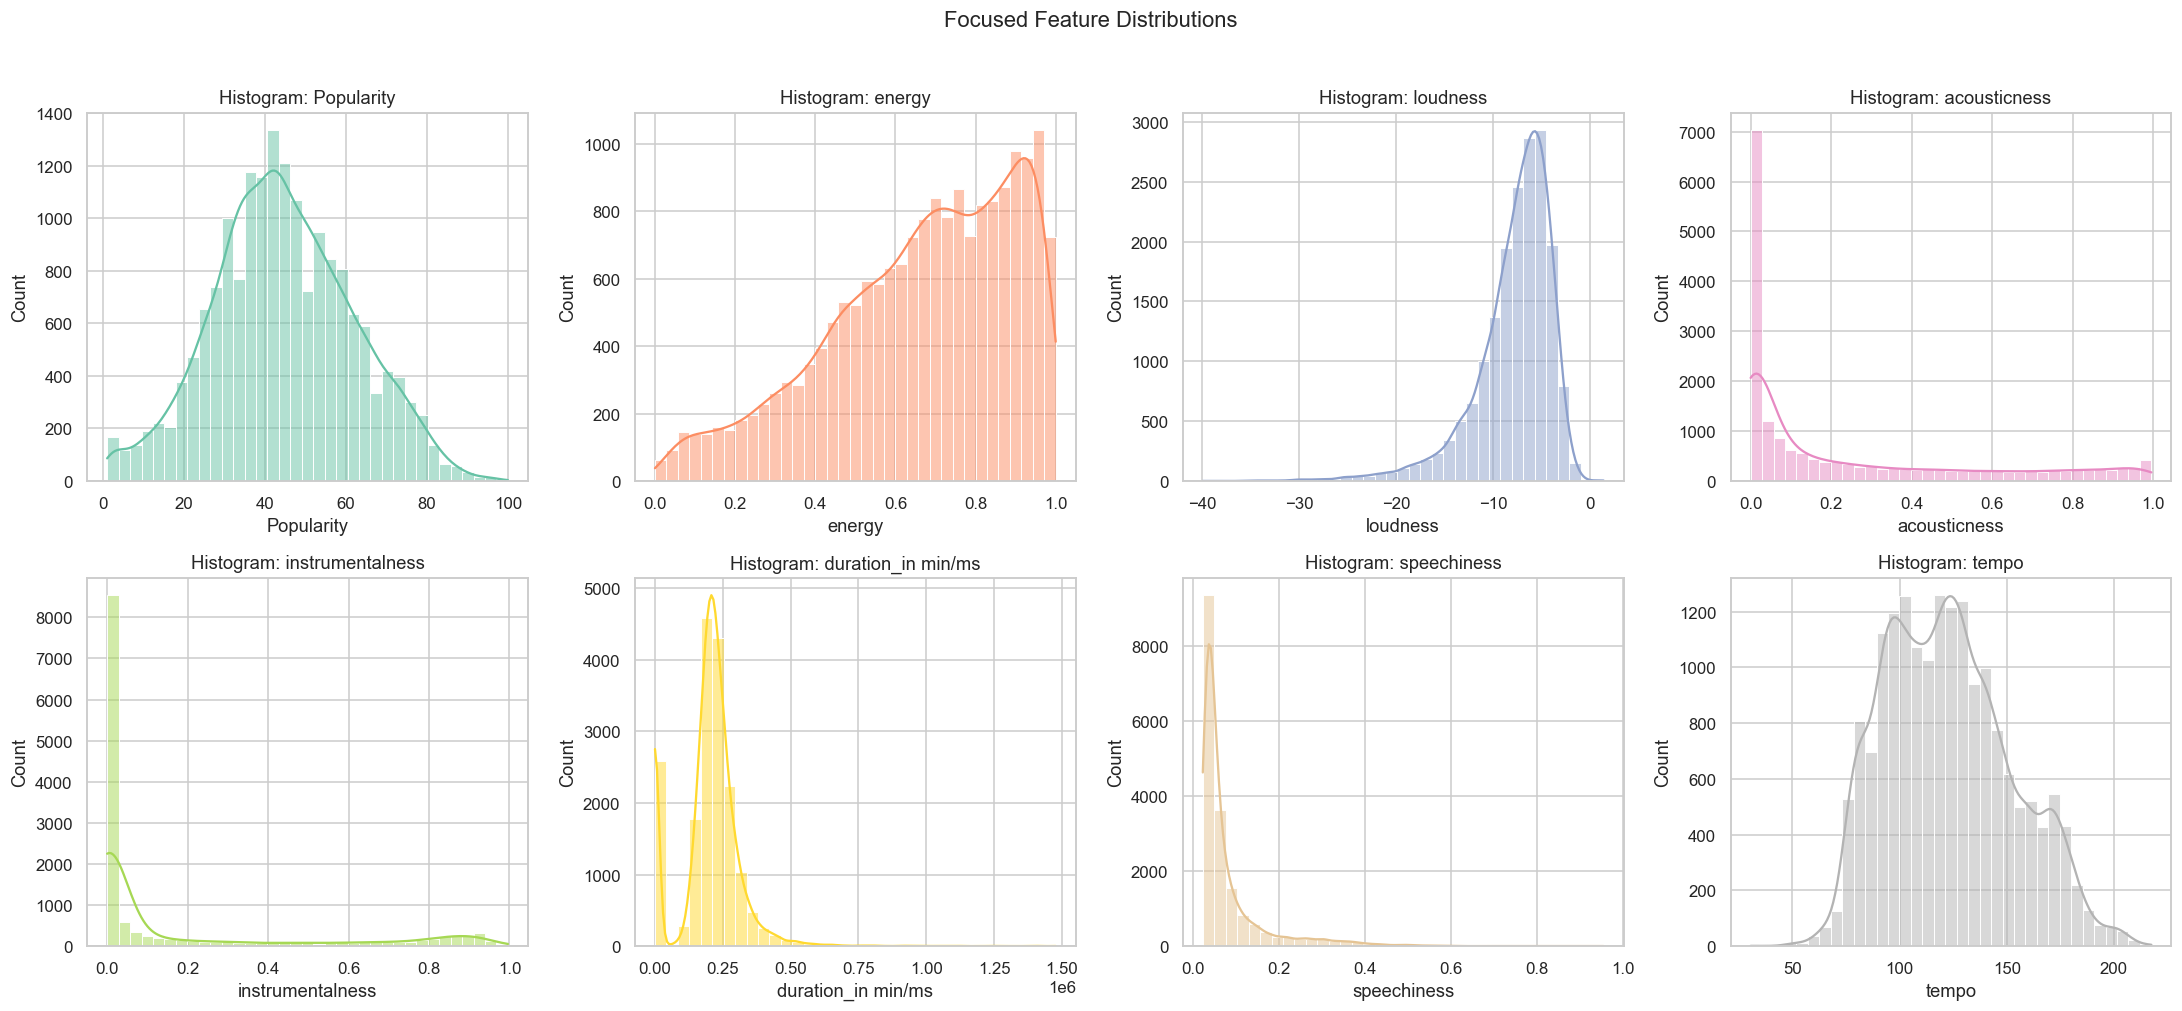

In [42]:
# Question: What are the distribution shapes and skew patterns of focused features?
plot_df = eda_df[FOCUSED_FEATURES].copy()
feature_palette = sns.color_palette(PALETTE, n_colors=len(FOCUSED_FEATURES))

fig, axes = plt.subplots(2, 4, figsize=FIGSIZE_WIDE)
for i, col in enumerate(FOCUSED_FEATURES):
    ax = axes[i // 4, i % 4]
    sns.histplot(plot_df[col], bins=35, kde=True, ax=ax, color=feature_palette[i])
    ax.set_title(f"Histogram: {col}")
    ax.set_xlabel(col)

plt.suptitle("Focused Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

- Histogram shape confirms that `speechiness`, `acousticness`, and `duration_in min/ms` are right-skewed (positive skew means a long right tail: most tracks sit at lower values with a smaller set of extreme high values).
- This skewness matters because tails can pull linear decision boundaries and distance metrics; robust scaling is preferred over standard scaling for these features, and `log1p` is a reasonable sensitivity check for heavy-tail variables.
- `instrumentalness` has both high missingness and a mass near low values, suggesting many vocal-dominant tracks with a minority of highly instrumental songs. Keep it, impute it, and add a missing-indicator so models can capture both value signal and missingness pattern.
- `duration_in min/ms` has wide spread and clear outliers; tree ensembles usually tolerate this directly, while linear or margin-based models should use clipping/transforms to reduce instability.

### 2.4. Outlier and Tail Diagnostics (Boxplots)

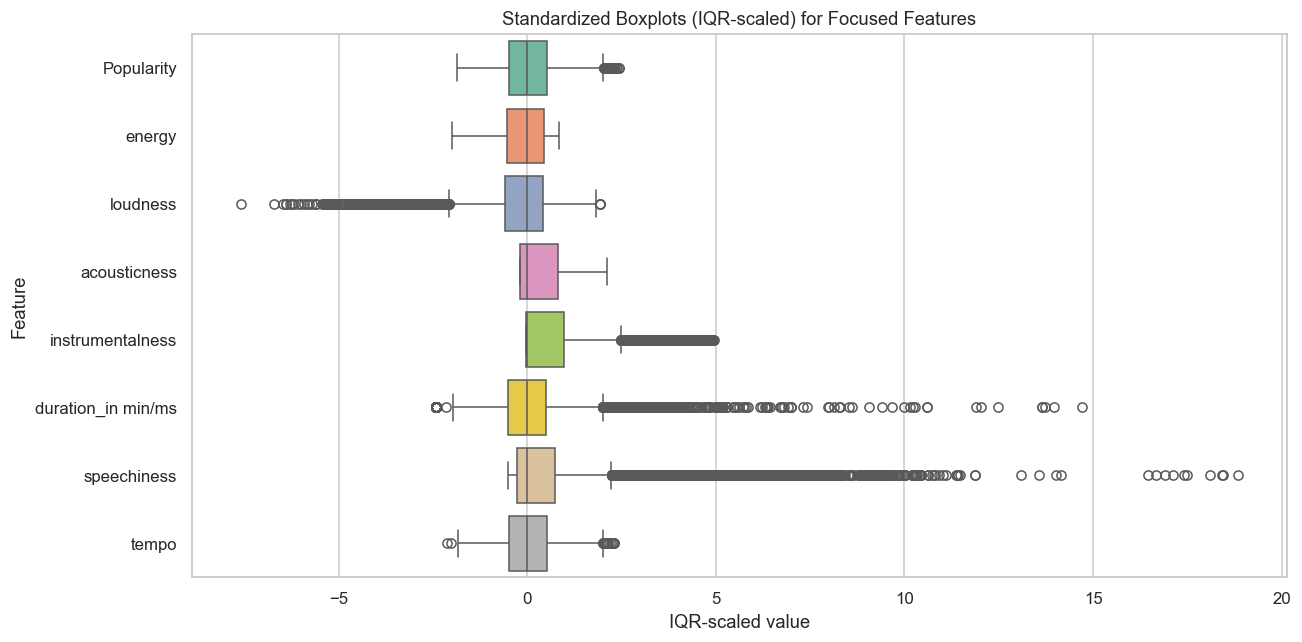

In [43]:
# Question: Which focused features have heavy tails or potential outliers?
long_df = eda_df[FOCUSED_FEATURES].melt(var_name="feature", value_name="value")
feature_palette = sns.color_palette(PALETTE, n_colors=len(FOCUSED_FEATURES))
feature_palette_map = dict(zip(FOCUSED_FEATURES, feature_palette))

# Standardize within feature so spread is comparable in one compact chart.
long_df["z_value"] = long_df.groupby("feature")["value"].transform(
    lambda x: (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25) + 1e-9)
)

plt.figure(figsize=FIGSIZE_MED)
sns.boxplot(
    data=long_df,
    x="z_value",
    y="feature",
    orient="h",
    whis=1.5,
    hue="feature",
    palette=feature_palette_map,
    legend=False,
)
plt.title("Standardized Boxplots (IQR-scaled) for Focused Features")
plt.xlabel("IQR-scaled value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

- The standardized boxplots reinforce a heavy-tail profile in several focused variables: `duration_in min/ms`, `speechiness`, and `acousticness` show broader IQR-scaled spread with more extreme points than relatively tighter features.
- `duration_in min/ms` stands out as the most outlier-prone feature, which supports using robust preprocessing (robust scaling and optional clipping/transform sensitivity checks) before linear or distance-based models.
- Outlier density differs by feature rather than appearing uniformly, so a feature-specific treatment strategy is preferable to global row-level outlier removal.
- Because many extreme values in music features can be genuine genre/style signal (not pure noise), keep these observations in baseline models and validate any clipping/removal via cross-validated ablations.

### 2.5. Correlation Structure of Focused Features

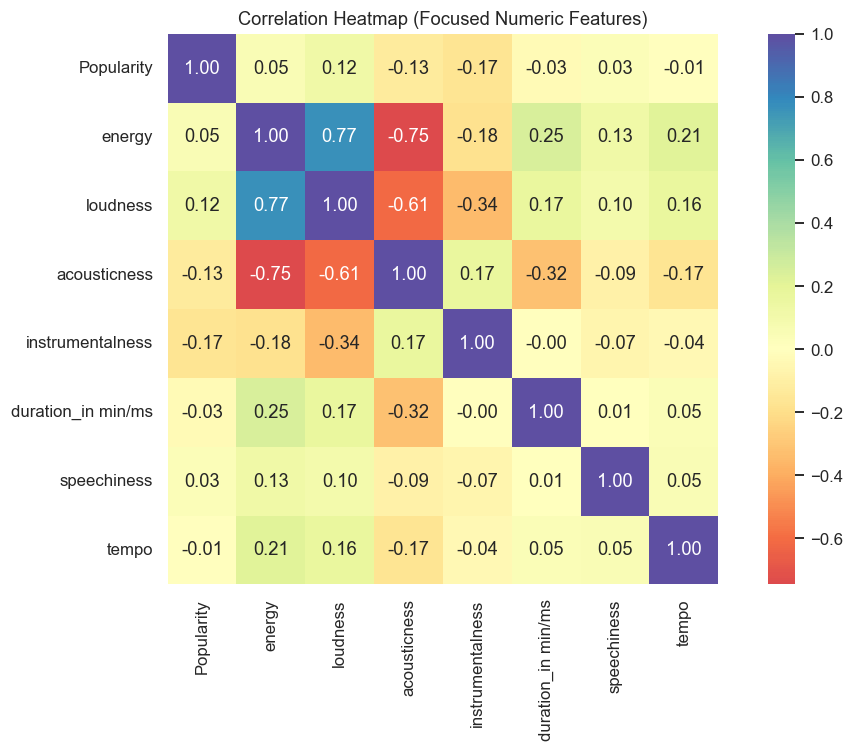

In [44]:
# Question: Which focused features move together strongly?
corr = eda_df[FOCUSED_FEATURES].corr()

plt.figure(figsize=FIGSIZE_HEATMAP)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Spectral", center=0, square=True)
plt.title("Correlation Heatmap (Focused Numeric Features)")
plt.tight_layout()
plt.show()

- The heatmap indicates a clear correlation cluster among `energy`, `loudness`, and `acousticness`, consistent with overlapping musical intensity/timbre structure in the feature space.
- This level of collinearity can destabilize coefficient estimates in unregularized linear models, so regularization (or feature-drop ablations) is important for interpretability and generalization.
- Correlation here should be treated as a redundancy signal, not automatic deletion logic: keep the cluster in baseline runs and verify value-add by model family (linear vs tree-based).
- Because `Class` is categorical, this matrix is useful for feature-feature dependency diagnostics only; class relevance should continue to be judged with class-aware methods (ANOVA/MI and class-conditional plots).

### 2.6. Strongest Pairwise Relationships (Scatterplots)

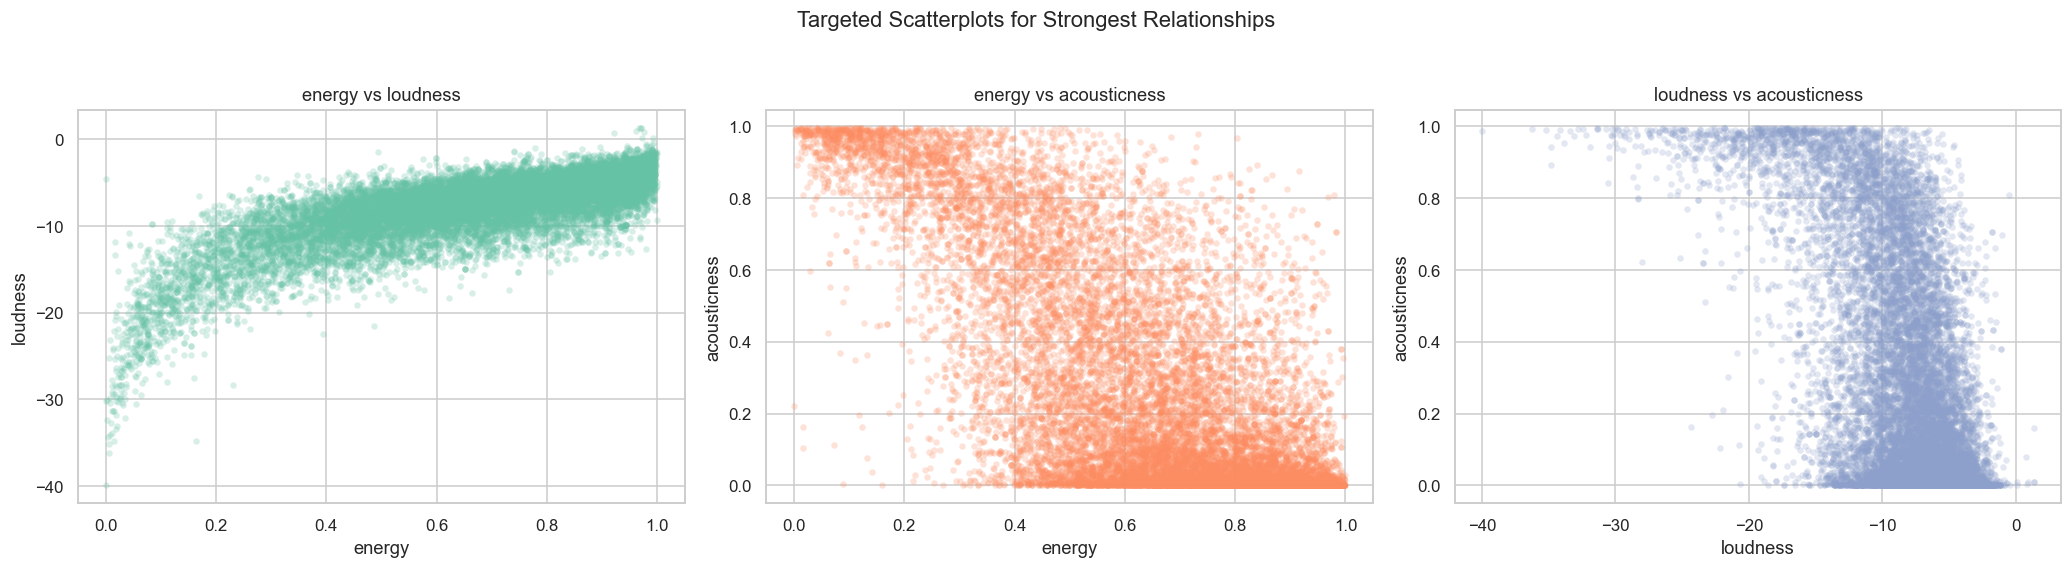

In [45]:
# Question: How do the strongest correlated feature pairs behave?
scatter_pairs = [
    ("energy", "loudness"),
    ("energy", "acousticness"),
    ("loudness", "acousticness"),
]
scatter_palette = sns.color_palette(PALETTE, n_colors=len(scatter_pairs))

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_THREE_PANEL)
for ax, (x_col, y_col), pair_color in zip(axes, scatter_pairs, scatter_palette):
    sns.scatterplot(
        data=eda_df,
        x=x_col,
        y=y_col,
        alpha=0.25,
        s=18,
        linewidth=0,
        ax=ax,
        color=pair_color,
    )
    ax.set_title(f"{x_col} vs {y_col}")

plt.suptitle("Targeted Scatterplots for Strongest Relationships", y=1.03)
plt.tight_layout()
plt.show()

Correlation conclusions for modeling:

- `energy`, `loudness`, and `acousticness` form a correlated cluster (strong pairwise relationships), so they are partially redundant for linear models and can inflate coefficient variance without regularization.
- Redundancy does **not** mean immediate removal. We keep the cluster initially because each feature can still add complementary nonlinear signal, especially for tree-based models.
- Practical strategy: keep all three for baseline models, then use regularization and ablation tests to decide whether dropping one improves generalization and interpretability.

### 2.7. Class Separation in Top Signal Features (MI + ANOVA)

,anova_f,anova_pvalue,mutual_info
duration_in min/ms,1484.9658,0.0,0.3509
acousticness,947.4509,0.0,0.2774
energy,833.6812,0.0,0.2139
instrumentalness,551.6458,0.0,0.1718
speechiness,807.7890,0.0,0.1414
loudness,785.5009,0.0,0.1303
Popularity,203.9523,0.0,0.0978
tempo,42.5693,0.0,0.0706


Top 3 class-signal features (categorical-safe ranking): ['duration_in min/ms', 'acousticness', 'energy']


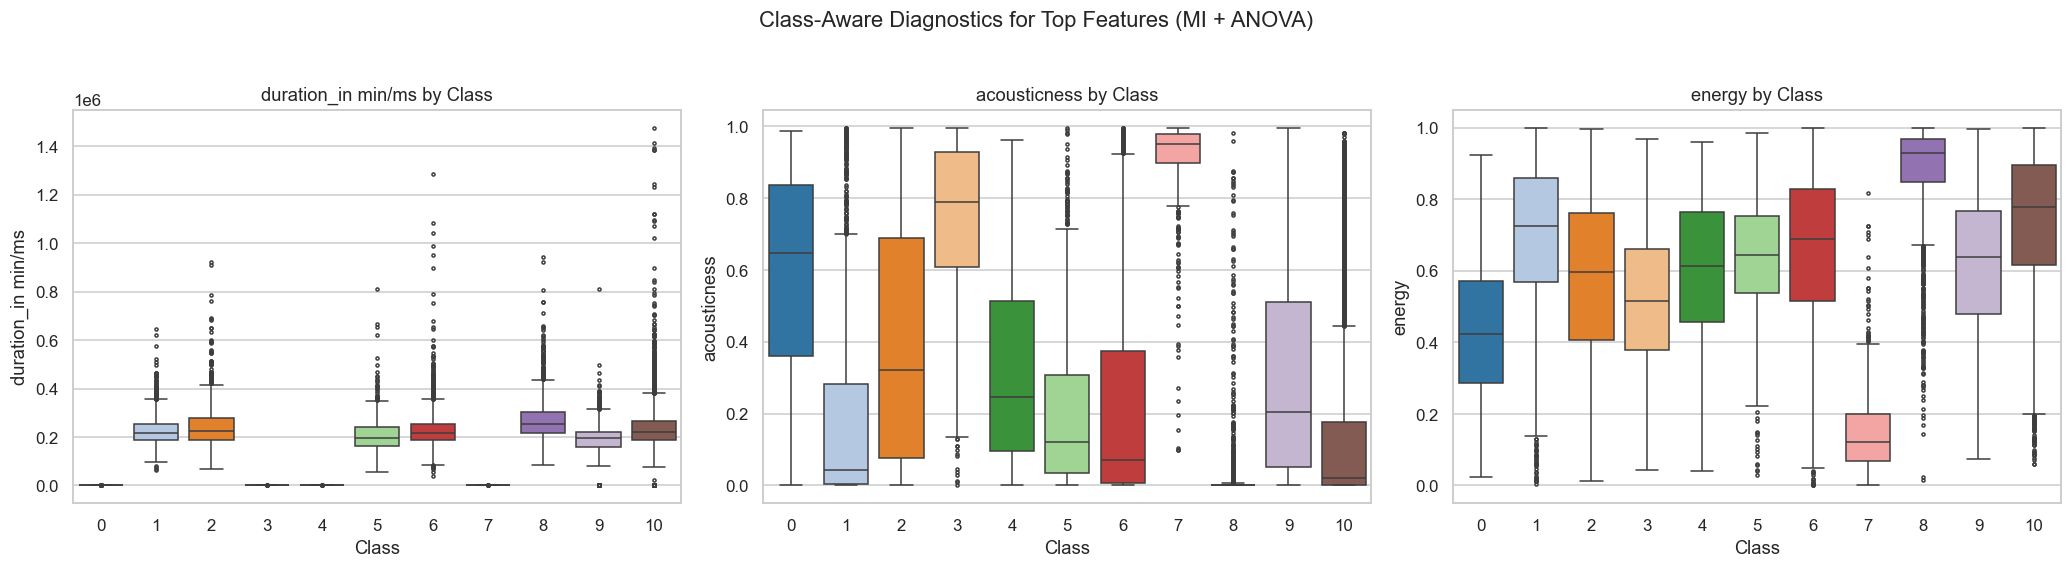

In [46]:
# Question: Which top signal features differ most across classes?
# `Class` is categorical, so Pearson correlation to class codes is not appropriate.
from sklearn.feature_selection import f_classif, mutual_info_classif

X = eda_df[FOCUSED_FEATURES].copy()
y = eda_df[TARGET_COL].copy()

# Handle missingness for score computation.
X_imputed = X.fillna(X.median(numeric_only=True))

f_vals, p_vals = f_classif(X_imputed, y)
mi_vals = mutual_info_classif(X_imputed, y, random_state=RANDOM_STATE)

signal_rank = pd.DataFrame({
    "anova_f": f_vals,
    "anova_pvalue": p_vals,
    "mutual_info": mi_vals,
}, index=FOCUSED_FEATURES).sort_values(["mutual_info", "anova_f"], ascending=False)

display(signal_rank.round(4))

top3_by_class_signal = signal_rank.head(3).index.tolist()
print("Top 3 class-signal features (categorical-safe ranking):", top3_by_class_signal)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_THREE_PANEL, sharex=False)
for ax, feature in zip(axes, top3_by_class_signal):
    sns.boxplot(
        data=eda_df,
        x=TARGET_COL,
        y=feature,
        ax=ax,
        hue=TARGET_COL,
        order=class_order,
        palette=class_palette_map,
        fliersize=2,
        legend=False,
    )
    ax.set_title(f"{feature} by Class")
    ax.set_xlabel(TARGET_COL)

plt.suptitle("Class-Aware Diagnostics for Top Features (MI + ANOVA)", y=1.03)
plt.tight_layout()
plt.show()

- The class-conditional boxplots confirm that top-ranked features from MI + ANOVA (`duration_in min/ms`, `acousticness`, `energy`) show meaningful distribution shifts across classes rather than uniform overlap.
- Separation is present but not cleanly linear: several classes still overlap in central ranges, indicating that interaction effects and nonlinear boundaries are likely important for final performance.
- `duration_in min/ms` contributes strong class signal, but its broad spread/outlier behavior suggests this feature should be paired with robust preprocessing checks (scaling/transform sensitivity in linear-distance models).
- Because rank metrics and boxplots agree directionally, these features are justified for baseline inclusion; final keep/drop decisions should still be made through cross-validated ablation by model family.

In [47]:
# Question: Is class imbalance large enough to affect model training and evaluation?
class_counts = df[TARGET_COL].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

class_balance = pd.DataFrame({
    "count": class_counts,
    "pct": class_pct,
})

print(f"Imbalance ratio (largest/smallest class): {imbalance_ratio:.2f}x")
class_balance

Imbalance ratio (largest/smallest class): 12.79x


,count,pct
Class,,
0,625,3.47
1,1373,7.63
2,1272,7.07
3,402,2.23
4,387,2.15
5,1447,8.04
6,2587,14.38
7,576,3.20
8,1854,10.30


### 2.8. Modeling implications

1. **Imputation:** `instrumentalness` has meaningful missingness, so keep median imputation and test a missing-indicator feature to capture any missingness signal.
2. **Encoding choices:** treat `key` as categorical (not continuous) if included; drop it if cross-validation shows negligible incremental gain.
3. **Scale/transform policy:** use robust scaling for skewed heavy-tail variables (`speechiness`, `acousticness`, `duration_in min/ms`, and potentially `instrumentalness`), then test `log1p` as an ablation for linear/distance-based models.
4. **Correlation management:** keep `energy`/`loudness`/`acousticness` in baseline runs; manage redundancy with regularization and feature-drop ablations, especially for linear models.
5. **Class-aware training/evaluation:** class imbalance is substantial enough to affect learning, so prioritize macro-F1 and balanced accuracy, use stratified folds, and try class weights before oversampling.
6. **Data-quality constraints are currently stable:** no exact duplicates and no bounded-range/invalid-zero violations were found, so avoid unnecessary row/value deletion and preserve signal.
7. **Validation discipline:** compare audio-only versus metadata-augmented variants, and keep all preprocessing inside a single cross-validated pipeline so EDA insights are validated, not assumed.

## 3. Data Quality and Cleaning

This section documents the data-quality checks and cleaning actions used before modeling.

**Run order:** Execute cells from top to bottom. Run the setup cell first, then run sections 3.1 to 3.8 in sequence so each step uses the updated `data` object from prior steps.

- **Missing values**
  - **Issue:** Missingness is concentrated in a few columns, especially `instrumentalness`, with smaller gaps in `Popularity` and `key`.
  - **Change:** Impute missing values in `instrumentalness`, `Popularity`, and `key` using each column median.
  - **Why reasonable:** Median imputation is robust to skew and extreme values and preserves sample size.
  - **Model impact:** Keeps training rows that would otherwise be dropped; however, imputation can compress variance near the center, so this should be validated in cross-validation.

- **Duplicate records**
  - **Issue checked:** Exact duplicate rows were audited.
  - **Finding:** No exact duplicates were found in this dataset snapshot.
  - **Change:** Keep `drop_duplicates(keep="first")` as a defensive, reproducible safeguard, while noting that row count remains unchanged.
  - **Why reasonable:** Duplicate audits still protect pipeline reliability when data sources are refreshed.
  - **Model impact:** No effect in the current run; prevents accidental reweighting if duplicates appear later.

- **Invalid ranges and invalid zeros**
  - **Issue checked:** Bounded audio features (for example `energy`, `danceability`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `speechiness`) should lie in `[0,1]`; variables like `tempo` and `duration_in min/ms` should be positive.
  - **Finding:** No bounded-range violations and no invalid zeros (`<= 0`) were detected in the audited columns.
  - **Change:** Preserve values as-is and retain these checks as automated guards.
  - **Why reasonable:** Constraint checks catch clearly invalid entries without arbitrary edits.
  - **Model impact:** Confirms current features are numerically plausible, reducing risk of scale distortion from corrupted inputs.

- **Outliers / extreme values**
  - **Issue:** Features such as `duration_in min/ms` and `tempo` can have heavy tails.
  - **Change:** Quantify outliers with an IQR-based diagnostic report; keep values unchanged in this notebook stage.
  - **Why reasonable:** For this dataset size, immediate trimming risks deleting valid rare songs; diagnostics-first is safer before model-based validation.
  - **Model impact:** Tree models are typically robust to extremes, while linear/distance models may need robust scaling or transforms in the modeling pipeline.

- **Inconsistent labels and clearly invalid entries**
  - **Issue checked:** Target label consistency and obvious invalid entries are reviewed via audits.
  - **Finding:** No missing target labels were found, and label cardinality is stable (`11` classes).
  - **Change:** Report findings explicitly; do not alter values unless a concrete rule is justified.
  - **Why reasonable:** Ensures transparency and reproducibility.
  - **Model impact:** Reduces hidden leakage/noise risks in downstream evaluation.

- **Feature inclusion decisions (preprocessing, not pure cleaning)**
  - `Artist Name` and `Track Name` are removed from this baseline because high-cardinality identifiers can cause leakage-like memorization and unstable generalization.
  - `danceability` and `mode` are also removed in this baseline to limit early feature-space complexity; this is treated as a modeling choice to validate by ablation, not as a claim that these variables are inherently invalid.

Overall, the policy is conservative: correct clear quality issues, preserve plausible observations, and defer aggressive transformations/removals until cross-validated modeling confirms a benefit.


### Setup

In [48]:
data = pd.read_csv(TRAIN_PATH)
print(f"Rows before cleaning: {len(data):,}")

Rows before cleaning: 17,996


### 3.1 Missing Values Audit (Before Cleaning)

Check missingness in key columns before any transformations.

In [49]:
missing_before = data[["instrumentalness", "Popularity", "key"]].isna().sum()
print("Missing values before imputation:")
print(missing_before)

Missing values before imputation:
instrumentalness    4377
Popularity           428
key                 2014
dtype: int64


### 3.2 Duplicate Audit and Removal

Count exact duplicates, remove them, and verify the post-cleaning row count.

In [50]:
dup_before = data.duplicated().sum()
print(f"Exact duplicates before removal: {dup_before:,}")

data = data.drop_duplicates(keep="first").copy()

dup_after = data.duplicated().sum()
print(f"Exact duplicates after removal: {dup_after:,}")
print(f"Rows after duplicate removal: {len(data):,}")

Exact duplicates before removal: 0
Exact duplicates after removal: 0
Rows after duplicate removal: 17,996


### 3.3 Median Imputation for Selected Columns

Impute missing values in `instrumentalness`, `key`, and `Popularity` using the column median.

In [51]:
impute_cols = ["instrumentalness", "key", "Popularity"]
for col in impute_cols:
    data[col] = data[col].fillna(data[col].median())

missing_after = data[impute_cols].isna().sum()
print("Missing values after imputation:")
print(missing_after)

Missing values after imputation:
instrumentalness    0
key                 0
Popularity          0
dtype: int64


### 3.4 Range Validity Checks for Bounded Features

Verify that bounded audio features are within `[0,1]`.

In [52]:
range_violations = {
    col: int(((data[col] < 0) | (data[col] > 1)).sum())
    for col in BOUNDED_FEATURES_01 if col in data.columns
}

print("Range violations for [0,1] features:")
print(pd.Series(range_violations).sort_values(ascending=False))

Range violations for [0,1] features:
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
dtype: int64


### 3.5 Invalid-Zero Checks

Check columns where values `<= 0` are implausible for observed measurements.

In [53]:
invalid_zero_fields = ["tempo", "duration_in min/ms"]
invalid_zero_counts = {
    col: int((data[col] <= 0).sum())
    for col in invalid_zero_fields if col in data.columns
}

print("Invalid-zero checks (<= 0):")
print(pd.Series(invalid_zero_counts).sort_values(ascending=False))

Invalid-zero checks (<= 0):
tempo                 0
duration_in min/ms    0
dtype: int64


### 3.6 IQR Outlier Diagnostics

Compute IQR-based outlier counts for selected features (diagnostic only).

In [54]:
outlier_features = ["tempo", "duration_in min/ms", "loudness", "Popularity", "instrumentalness"]
iqr_report = []
for col in outlier_features:
    if col not in data.columns:
        continue
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = int(((data[col] < lower) | (data[col] > upper)).sum())
    iqr_report.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(data) * 100, 3),
    })

print("IQR outlier diagnostic report (no values removed):")
print(pd.DataFrame(iqr_report).sort_values("outlier_pct", ascending=False))

IQR outlier diagnostic report (no values removed):
              feature             q1            q3           iqr  \
4    instrumentalness       0.000294       0.05660      0.056306   
1  duration_in min/ms  166337.000000  252490.00000  86153.000000   
2            loudness      -9.538000      -5.18900      4.349000   
3          Popularity      33.000000      56.00000     23.000000   
0               tempo      99.620750     141.96925     42.348500   

    lower_bound    upper_bound  outlier_count  outlier_pct  
4     -0.084165       0.141059           3714       20.638  
1  37107.500000  381719.500000           3245       18.032  
2    -16.061500       1.334500            818        4.545  
3     -1.500000      90.500000             41        0.228  
0     36.098000     205.492000             36        0.200  


### 3.7 Target Label Sanity Checks

Check missing target labels and label cardinality.

In [55]:
print("Target label checks:")
print(f"Missing Class labels: {int(data['Class'].isna().sum())}")
print(f"Unique Class labels: {int(data['Class'].nunique())}")

Target label checks:
Missing Class labels: 0
Unique Class labels: 11


### 3.8 Baseline Feature-Removal Snapshot (Modeling Choice)

Create the baseline modeling dataframe after conservative cleaning and selected column drops.

In [56]:
baseline_drop_cols = ["Artist Name", "Track Name", "mode", "danceability"]
data_model = data.drop(columns=[c for c in baseline_drop_cols if c in data.columns])

print("Columns dropped for baseline modeling:", baseline_drop_cols)
print(f"Rows retained for modeling: {len(data_model):,}")
print(f"Columns retained for modeling: {data_model.shape[1]}")

Columns dropped for baseline modeling: ['Artist Name', 'Track Name', 'mode', 'danceability']
Rows retained for modeling: 17,996
Columns retained for modeling: 13


## 4. Model Readiness Reflection

### 4.1. Most important patterns
- Genre prediction is feasible but non-trivial: classes overlap in several feature ranges, so purely linear boundaries are likely insufficient.
- `energy`, `loudness`, and `acousticness` form a correlated cluster; this indicates partial redundancy risk in linear models, but not automatic removal.
- Heavy-tail behavior is visible in features such as `duration_in min/ms`, `speechiness`, and `acousticness`, so preprocessing robustness matters.

### 4.2. Most important data quality issues
- Missingness is concentrated in a few columns (especially `instrumentalness`, with smaller gaps in `Popularity` and `key`), so imputation is preferred over dropping rows.
- Exact duplicate records should be removed to avoid overweighting repeated examples.
- Range/validity checks are necessary (bounded features in `[0,1]`, positive `tempo`/`duration_in min/ms`) before modeling.

### 4.3. Useful features (evidence-based)
- The strongest class-signal features from MI + ANOVA are `duration_in min/ms`, `acousticness`, and `energy`.
- `duration_in min/ms` appears especially important and should be kept in baseline models unless cross-validated ablation proves otherwise.
- `speechiness` is also meaningful and should be treated as a useful supporting feature.
- Feature usefulness must be confirmed by leakage-safe cross-validation and ablation, not EDA alone.

### 4.4. Preprocessing and modeling challenges
- Balancing signal retention vs redundancy: keep correlated features in baseline runs, then evaluate drop/keep via regularized models and ablation.
- Handling skew/outliers without deleting valid rare tracks: use robust scaling and test `log1p` sensitivity for linear/distance-based models.
- Managing class imbalance: prioritize macro-F1 and balanced accuracy, and use class-aware training strategies.
- Controlling leakage risk from metadata/high-cardinality identifiers: compare audio-only vs metadata-augmented models under the same CV protocol.

### 4.5. Final readiness statement
The dataset is ready for baseline modeling with a conservative pipeline: deduplicate, validate ranges, impute missing values, keep high-signal audio features (especially `duration_in min/ms`, `acousticness`, `energy`), and finalize feature decisions through cross-validated model comparison and ablation.